In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os

# Ensure we can import our local package
# Ensure we can import our local package
sys.path.append(os.getcwd())
sys.path.append('./..')

from src import solver, plotting, utils, constants as c, utils

# Visualization Settings
%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12

Warm Start: Found similar model in DB. Initial log_Pc = 8.5750
Solving for 1.0 Mj planet...
[START INTEGRATION] Pc=1.19e+08 -> P_int=8.18e+07 -> T_int=23743.5 K
[SUCCESS] M=0.654 Mj
  [Debug] Jupiter_WarmStart logPc: 8.08 -> Mass: 0.654 Mj
[START INTEGRATION] Pc=1.19e+09 -> P_int=1.02e+09 -> T_int=54943.0 K
[SUCCESS] M=2.346 Mj
  [Debug] Jupiter_WarmStart logPc: 9.08 -> Mass: 2.346 Mj
[START INTEGRATION] Pc=1.19e+08 -> P_int=8.18e+07 -> T_int=23743.5 K
[SUCCESS] M=0.654 Mj
  [Debug] Jupiter_WarmStart logPc: 8.08 -> Mass: 0.654 Mj
[START INTEGRATION] Pc=1.19e+09 -> P_int=1.02e+09 -> T_int=54943.0 K
[SUCCESS] M=2.346 Mj
  [Debug] Jupiter_WarmStart logPc: 9.08 -> Mass: 2.346 Mj
[START INTEGRATION] Pc=1.90e+08 -> P_int=1.41e+08 -> T_int=27613.6 K
[SUCCESS] M=0.881 Mj
  [Debug] Jupiter_WarmStart logPc: 8.28 -> Mass: 0.881 Mj
[START INTEGRATION] Pc=2.39e+08 -> P_int=1.81e+08 -> T_int=29890.7 K
[SUCCESS] M=1.009 Mj
  [Debug] Jupiter_WarmStart logPc: 8.38 -> Mass: 1.009 Mj
[START INTEGRATION] 

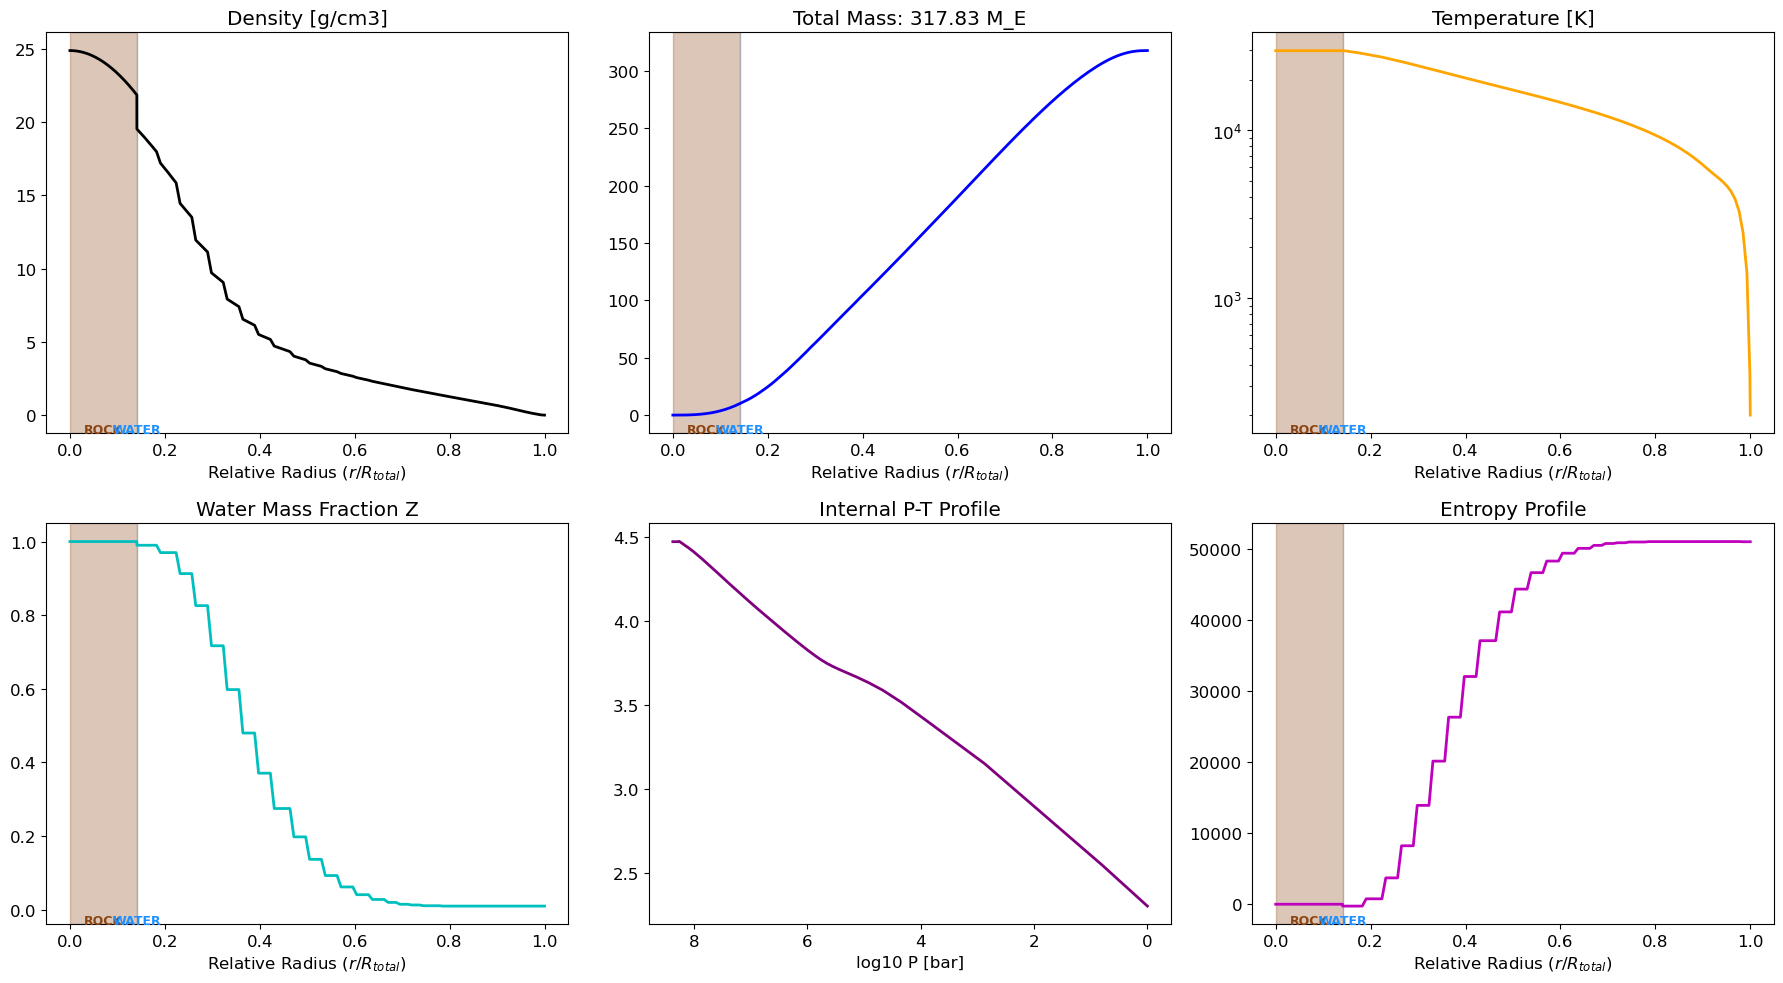

Figure saved to: ../figures/eos_trajectory.pdf


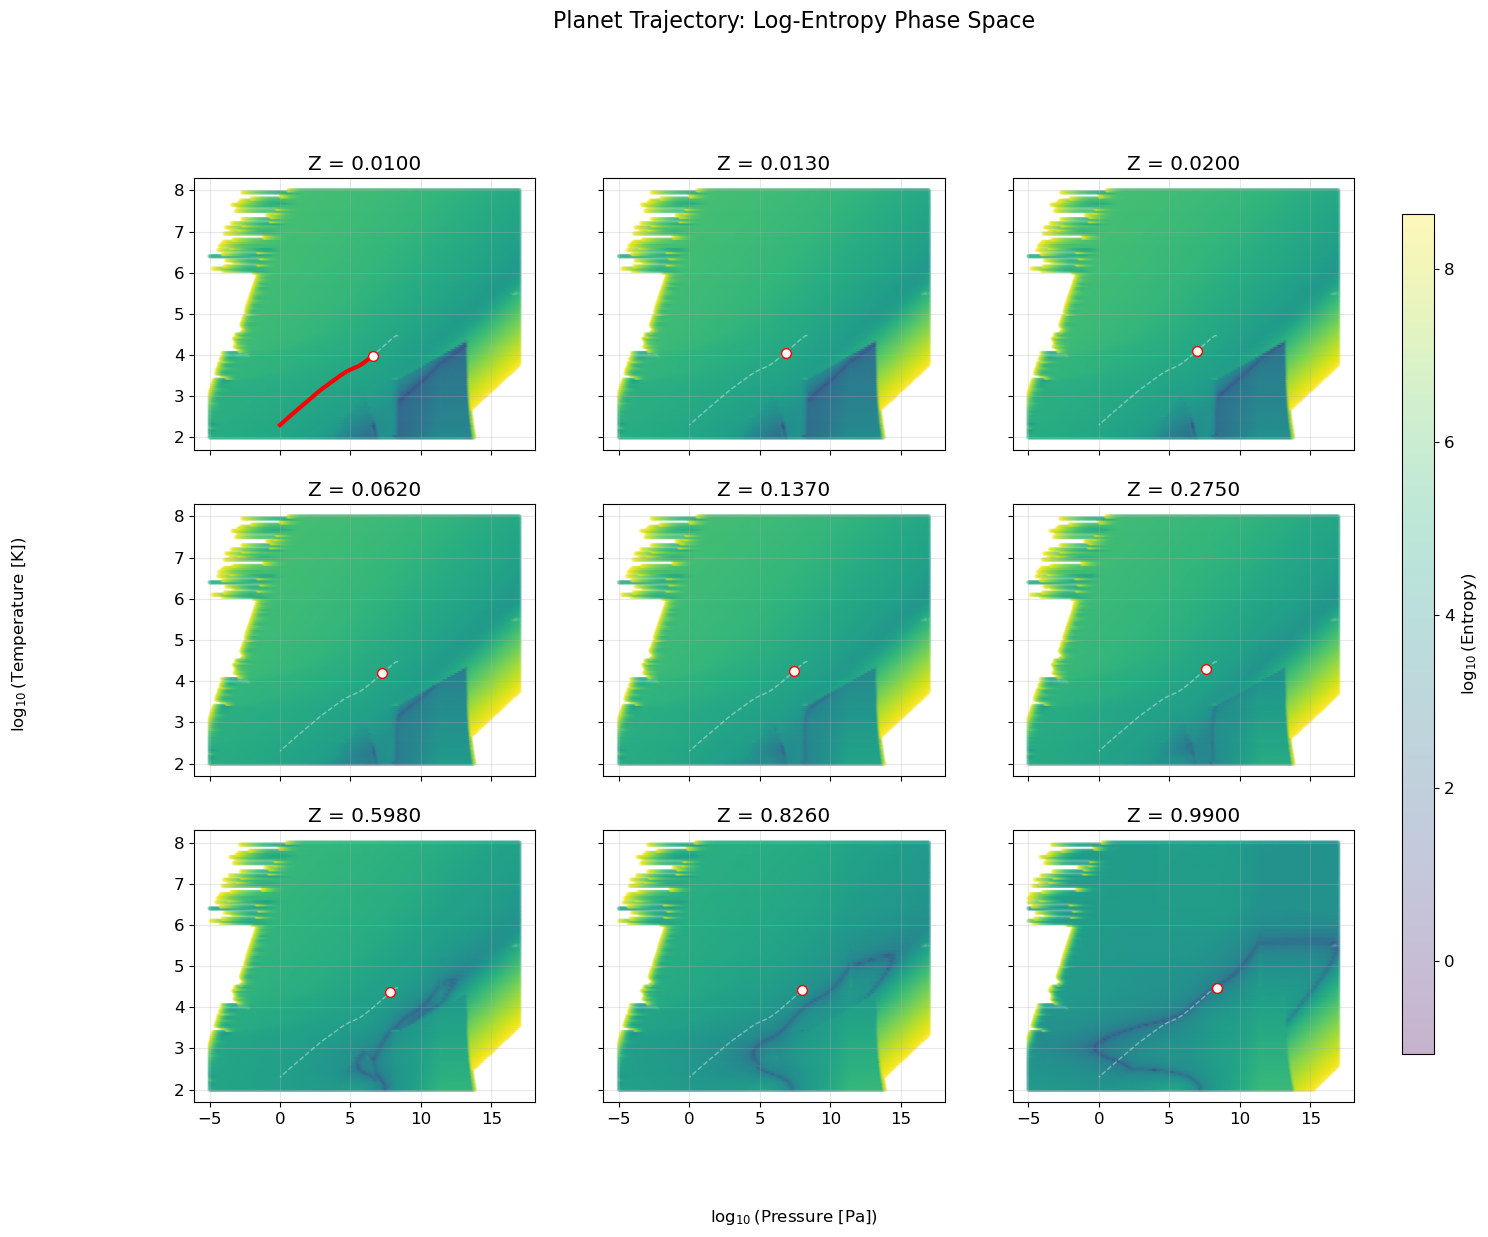

In [5]:
# 1. Setup Parameters for the target model
target_mass = 1.0 * c.M_JUPITER
params = {
    'M_core': 10.0 * c.M_EARTH,   
    'P_surf': 1.0,               
    'T_surf': 200.0,             
    'z_base': 0.01,              
    'sigma_val': 0.05,    
    'debug' : True        
}

# 2. Extract Initial Guess from Database
db_path = "../data/dilute_core_p_surf_study.csv"
initial_log_pc = 12.5 # Default fallback

if os.path.exists(db_path):
    df_db = pd.read_csv(db_path)
    # Filter for successful runs with similar parameters
    success_df = df_db[df_db['status'].str.contains('success', na=False)].copy()
    
    if not success_df.empty:
        # Find the model closest in Mass and Temperature
        success_df['dist'] = (
            np.abs(success_df['M_total_Mj'] - (target_mass/c.M_JUPITER)) + 
            np.abs(success_df['T_surf_K'] - params['T_surf']) / 100.0
        )
        best_match = success_df.loc[success_df['dist'].idxmin()]
        initial_log_pc = np.log10(best_match['P_center_bar'])
        print(f"Warm Start: Found similar model in DB. Initial log_Pc = {initial_log_pc:.4f}")
    else:
        print("DB exists but no successful models found. Using default guess.")
else:
    print("Database not found. Using default guess.")

params['initial_log_pc'] = initial_log_pc

# 3. Generate high-resolution Z-profile
params['z_profile'] = np.round(utils.generate_gaussian_z_profile(
    n_layers=100, 
    sigma=params['sigma_val'], 
    z_base=params['z_base'], 
    z_core=0.99
), 3)

# 4. Solve for the internal structure
print(f"Solving for {target_mass/c.M_JUPITER:.1f} Mj planet...")
result = solver.solve_structure(
    target_val=target_mass, 
    params=params, 
    mode='mass', 
    trial_id="Jupiter_WarmStart", 
    csv_file="test_run.csv", 
    write_lock=utils.DummyLock() 
)

if result:
    print(f"Success! Calculated Mass: {result['M'][-1]/c.M_JUPITER:.3f} Mj")
    print(f"Radius found {np.max(result['R'])/c.R_JUPITER:.3f} Rj")
    plotting.plot_diagnostics(result)
    plotting.plot_trajectory_on_eos(result, params, max_plots=9)

Solving for 8.17 Me Water World...
  > Rock:  7.10 Me
  > Water: 1.00 Me
  > Env:   0.07 Me
  [Debug] GJ_1214_b_Hycean logPc: 7.50 -> Mass: 0.154 Mj
  [Debug] GJ_1214_b_Hycean logPc: 8.50 -> Mass: 0.687 Mj
  [Debug] GJ_1214_b_Hycean logPc: 7.00 -> Mass: 0.050 Mj
  [Debug] GJ_1214_b_Hycean logPc: 7.50 -> Mass: 0.154 Mj
  [Solver] logPc 6.50: Integration returned None
  [Debug] GJ_1214_b_Hycean logPc: 7.00 -> Mass: 0.050 Mj
  [Solver] logPc 6.50: Integration returned None
  [Debug] GJ_1214_b_Hycean logPc: 7.00 -> Mass: 0.050 Mj
  [Debug] GJ_1214_b_Hycean logPc: 7.00 -> Mass: 0.050 Mj
  [Debug] GJ_1214_b_Hycean logPc: 6.80 -> Mass: 0.027 Mj
  [Solver] logPc 6.65: Integration returned None
  [Debug] GJ_1214_b_Hycean logPc: 6.80 -> Mass: 0.027 Mj
  [Solver] logPc 6.72: Integration returned None
  [Debug] GJ_1214_b_Hycean logPc: 6.80 -> Mass: 0.027 Mj
  [Debug] GJ_1214_b_Hycean logPc: 6.79 -> Mass: 0.026 Mj
  [Debug] GJ_1214_b_Hycean logPc: 6.79 -> Mass: 0.025 Mj
  [Debug] GJ_1214_b_Hycean l

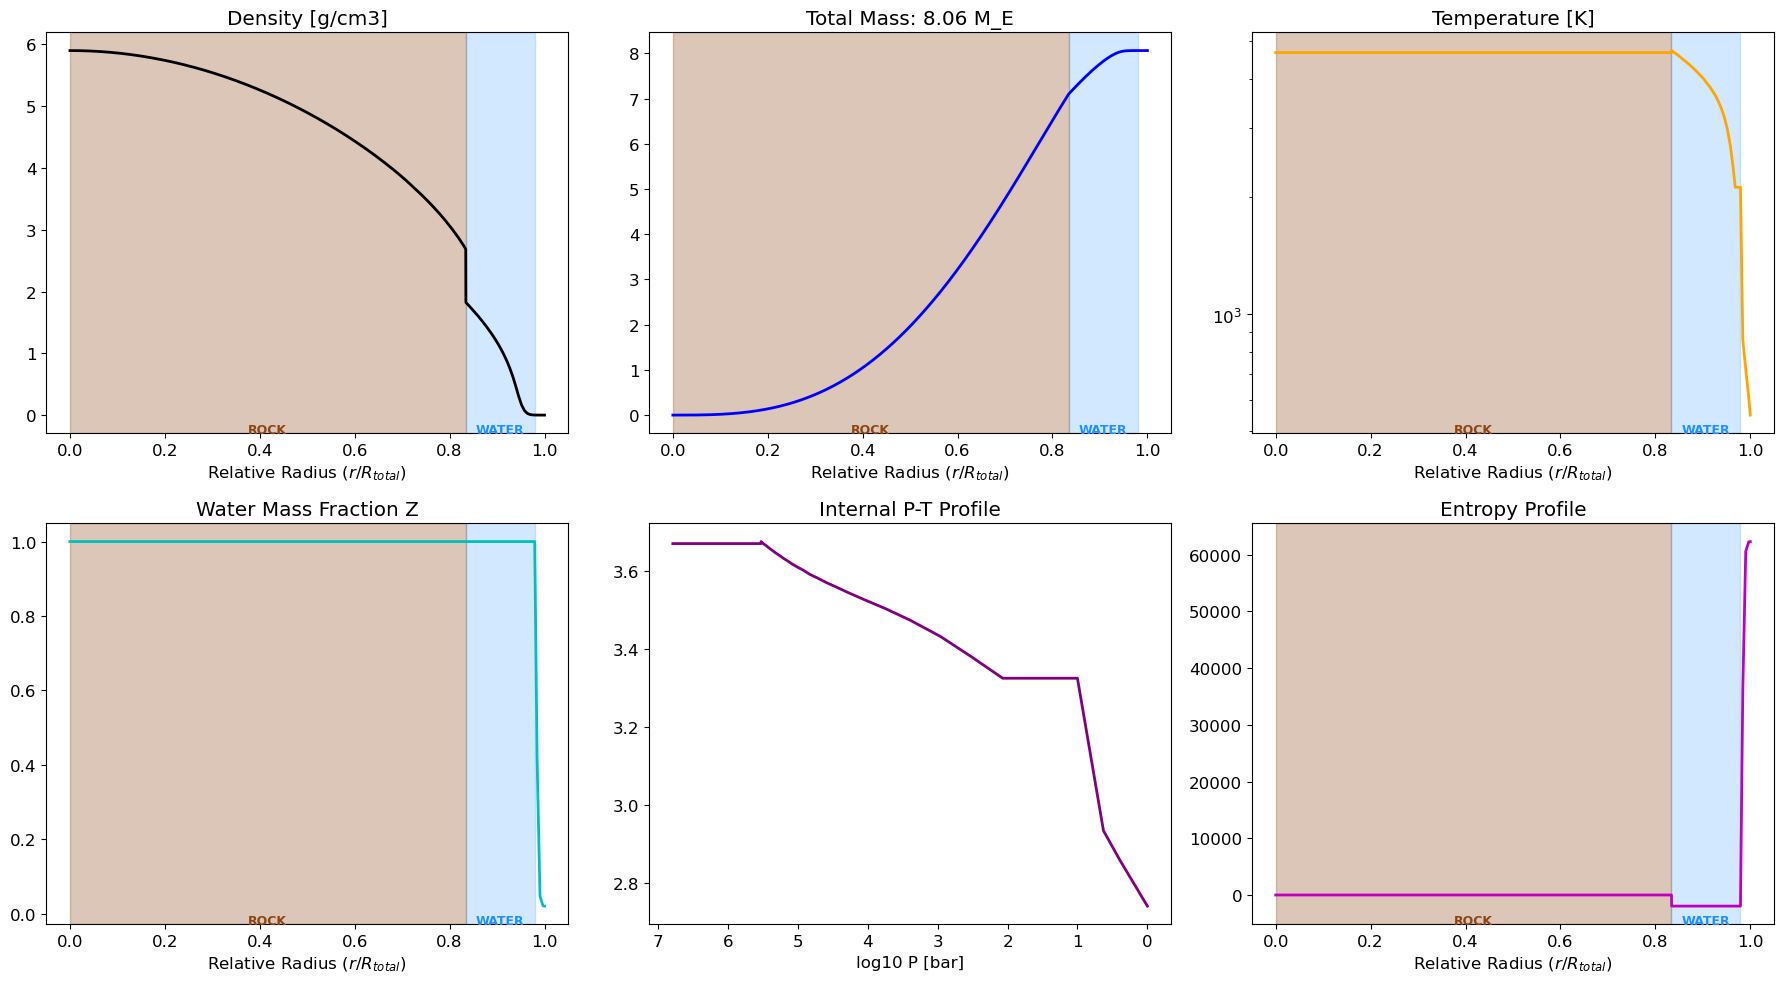

In [13]:
# 1. Setup Parameters for K2-18b (Hycean Candidate)
GJ_1214_b = 8.17 * c.M_EARTH  # Refined Mass

params = {
    # Interior: Must be small to allow a massive, thick envelope
    'M_rock': 7.1 * c.M_EARTH,   
    
    # We set water to 0.0. Kepler-11e is too hot and gas-dominated 
    # for a distinct liquid/ice mantle. Metals are mixed in the envelope.
    'M_water': 1.0 * c.M_EARTH,  
    
    # Surface Conditions
    'P_surf': 1.0,               
    'T_surf': 550.0,  # Kepler-11e is highly irradiated (T_eq is ~880-900 K)
    
    # Atmosphere Composition
    'z_base': 0.02,   # Mostly H/He at the surface
    
    # A wide dilute region (fuzzy core) lofts heavy elements into the 
    # envelope, restricting convection and puffing the radius up even further.
    'sigma_val': 0.25, 
    
    # Iron fraction for the rock core (Earth-like)
    'iron_fraction': 0.33,
    
    'debug': True           
}

# Calculated Envelope Mass: 8.6 - 8.0 = 0.6 Me (~7% envelope, realistic for Mini-Neptune)

# 2. Extract Initial Guess (Warm Start)
db_path = "../data/dilute_core_p_surf_study.csv"
initial_log_pc = 8.0 # Core pressure will be higher for a solid planet (~30 Mbar)

if os.path.exists(db_path):
    try:
        df_db = pd.read_csv(db_path)
        # Filter for successful runs
        success_df = df_db[df_db['status'].astype(str).str.contains('success', na=False)].copy()
        
        if not success_df.empty:
            # Find nearest mass neighbor
            success_df['dist'] = np.abs(success_df['M_total_Mj'] - (GJ_1214_b/c.M_JUPITER))
            best_match = success_df.loc[success_df['dist'].idxmin()]
            
            # Sanity check the pressure (don't blindly trust a Jupiter run for a Earth run)
            found_pc = np.log10(best_match['P_center_bar'])
            if 9.0 < found_pc < 13.0:
                initial_log_pc = found_pc
                print(f"Warm Start: Found similar model. Initial log_Pc = {initial_log_pc:.4f}")
    except:
        print("Database read error. Using default.")

params['initial_log_pc'] = initial_log_pc

# 3. Generate Z-profile (H/He Surface -> Water/Rock Interior)
params['z_profile'] = np.round(utils.generate_gaussian_z_profile(
    n_layers=100, 
    sigma=params['sigma_val'], 
    z_base=params['z_base'], 
    z_core=0.99
), 3)

# 4. Run Solver
# The solver detects 'M_water' and uses the 3-layer integrator automatically
print(f"Solving for {GJ_1214_b/c.M_EARTH:.2f} Me Water World...")
print(f"  > Rock:  {params['M_rock']/c.M_EARTH:.2f} Me")
print(f"  > Water: {params['M_water']/c.M_EARTH:.2f} Me")
print(f"  > Env:   {(GJ_1214_b - params['M_rock'] - params['M_water'])/c.M_EARTH:.2f} Me")

result = solver.solve_structure(
    target_val=GJ_1214_b, 
    params=params, 
    mode='mass', 
    trial_id="GJ_1214_b_Hycean", 
    csv_file="hycean_runs.csv", 
    write_lock=utils.DummyLock() 
)

# 5. Quick Result Check
if result:
    print("\n--- SOLUTION FOUND ---")
    print(f"Total Mass:   {result['M_total']/c.M_EARTH:.3f} M_E")
    print(f"Total Radius: {result['R_total']/c.R_EARTH:.3f} R_E")
    print(f"Core Radius:  {result['R_rock']/c.R_EARTH:.3f} R_E (Rock)")
    print(f"Water Top:    {result['R_int']/c.R_EARTH:.3f} R_E")
    
    # Plotting
    plotting.plot_diagnostics(result, save_name="GJ_1214_b_structure")
else:
    print("\n[FAILED] Solver could not converge.")

In [14]:
result

{'M_total': 4.815542634948202e+25,
 'R_total': 16170768.603860537,
 'M_Z_total': 4.815520029888302e+25,
 'R': array([6.00000000e+02, 2.56000000e+04, 5.06000000e+04, 7.56000000e+04,
        1.00600000e+05, 1.25600000e+05, 1.50600000e+05, 1.75600000e+05,
        2.00600000e+05, 2.25600000e+05, 2.50600000e+05, 2.75600000e+05,
        3.00600000e+05, 3.25600000e+05, 3.50600000e+05, 3.75600000e+05,
        4.00600000e+05, 4.25600000e+05, 4.50600000e+05, 4.75600000e+05,
        5.00600000e+05, 5.25600000e+05, 5.50600000e+05, 5.75600000e+05,
        6.00600000e+05, 6.25600000e+05, 6.50600000e+05, 6.75600000e+05,
        7.00600000e+05, 7.25600000e+05, 7.50600000e+05, 7.75600000e+05,
        8.00600000e+05, 8.25600000e+05, 8.50600000e+05, 8.75600000e+05,
        9.00600000e+05, 9.25600000e+05, 9.50600000e+05, 9.75600000e+05,
        1.00060000e+06, 1.02560000e+06, 1.05060000e+06, 1.07560000e+06,
        1.10060000e+06, 1.12560000e+06, 1.15060000e+06, 1.17560000e+06,
        1.20060000e+06, 1.2

Solving for 7.95 Me Water World...
  > Rock:  7.00 Me
  > Water: 0.20 Me
  > Env:   0.75 Me
  [Debug] Kepler11e_Hycean logPc: 7.50 -> Mass: 0.175 Mj
  [Debug] Kepler11e_Hycean logPc: 8.50 -> Mass: 0.732 Mj
  [Debug] Kepler11e_Hycean logPc: 7.00 -> Mass: 0.056 Mj
  [Debug] Kepler11e_Hycean logPc: 7.50 -> Mass: 0.175 Mj
  [Solver] logPc 6.50: Integration returned None
  [Debug] Kepler11e_Hycean logPc: 7.00 -> Mass: 0.056 Mj
  [Solver] logPc 6.50: Integration returned None
  [Debug] Kepler11e_Hycean logPc: 7.00 -> Mass: 0.056 Mj
  [Debug] Kepler11e_Hycean logPc: 7.00 -> Mass: 0.056 Mj
  [Debug] Kepler11e_Hycean logPc: 6.75 -> Mass: 0.025 Mj
  [Debug] Kepler11e_Hycean logPc: 6.75 -> Mass: 0.025 Mj
  [Debug] Kepler11e_Hycean logPc: 6.75 -> Mass: 0.025 Mj
  [Debug] Kepler11e_Hycean logPc: 6.75 -> Mass: 0.025 Mj
  [Debug] Kepler11e_Hycean logPc: 6.75 -> Mass: 0.025 Mj
  [Solver] logPc 6.62: Integration returned None
  [Debug] Kepler11e_Hycean logPc: 6.75 -> Mass: 0.025 Mj

--- SOLUTION FOUND 

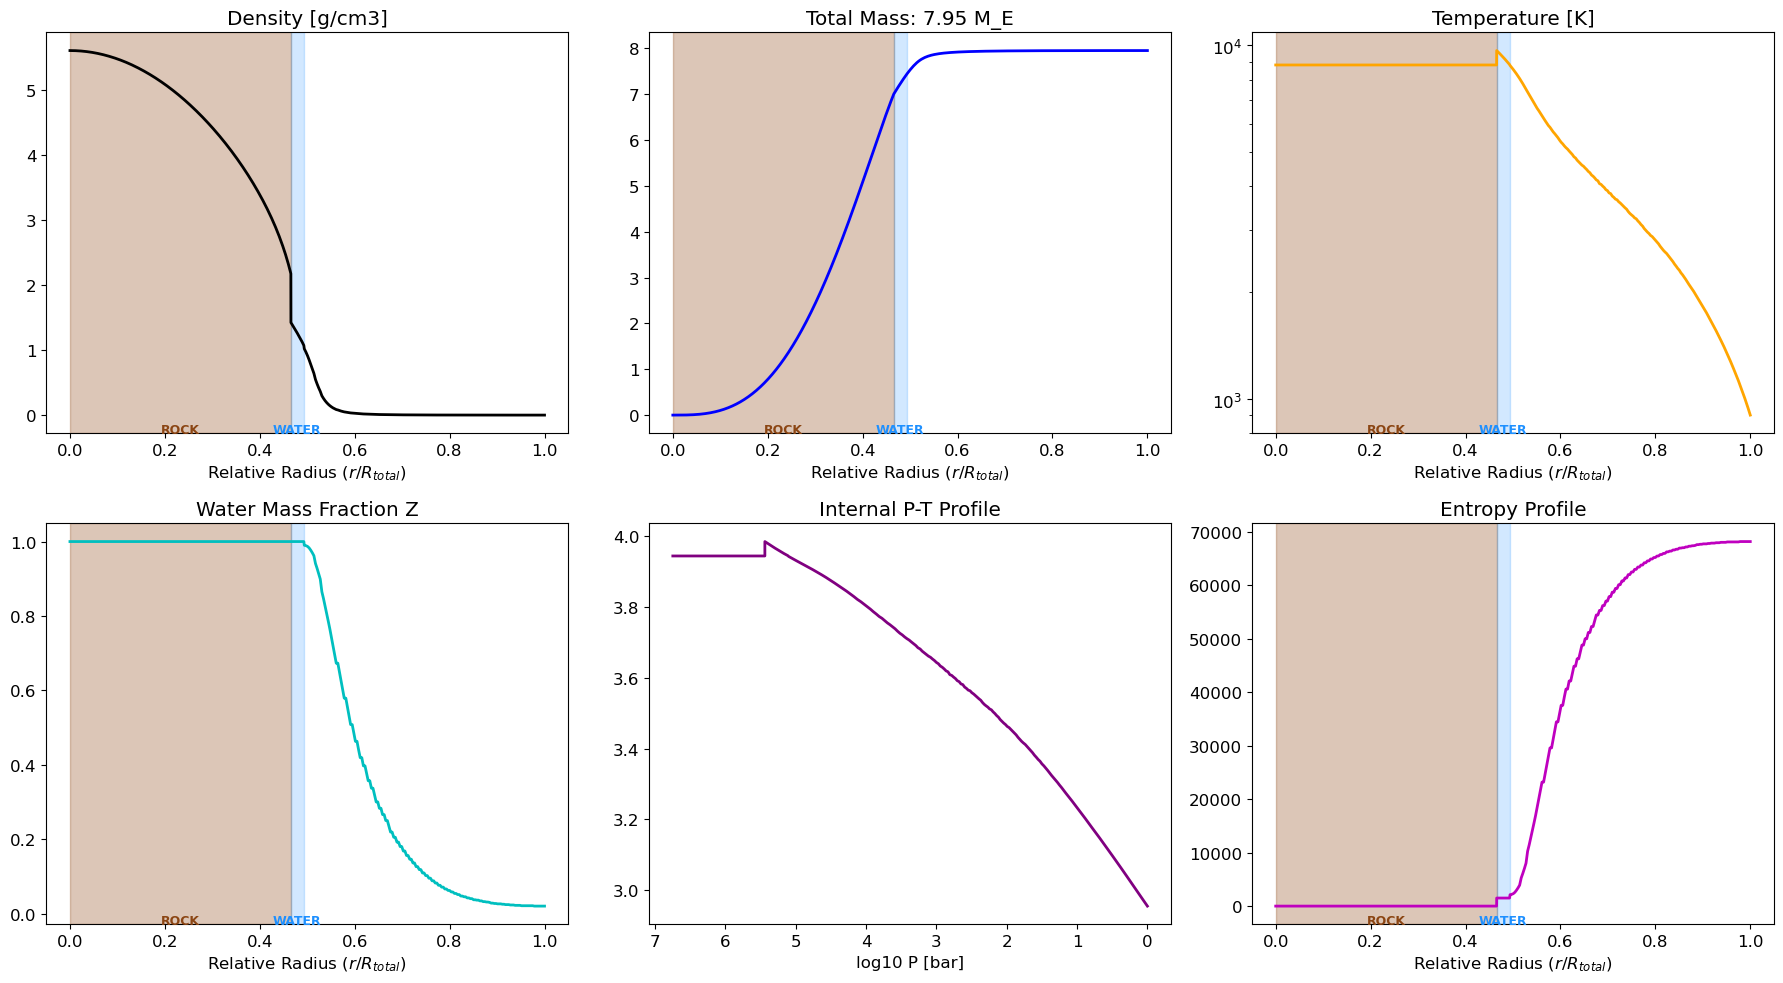

In [15]:
# 1. Setup Parameters for K2-18b (Hycean Candidate)
M_Kepler11e = 7.945 * c.M_EARTH  # Refined Mass

params = {
    # Interior: Must be small to allow a massive, thick envelope
    'M_rock': 7 * c.M_EARTH,   
    
    # We set water to 0.0. Kepler-11e is too hot and gas-dominated 
    # for a distinct liquid/ice mantle. Metals are mixed in the envelope.
    'M_water': 0.2 * c.M_EARTH,  
    
    # Surface Conditions
    'P_surf': 1.0,               
    'T_surf': 900.0,  # Kepler-11e is highly irradiated (T_eq is ~880-900 K)
    
    # Atmosphere Composition
    'z_base': 0.02,   # Mostly H/He at the surface
    
    # A wide dilute region (fuzzy core) lofts heavy elements into the 
    # envelope, restricting convection and puffing the radius up even further.
    'sigma_val': 0.25, 
    
    # Iron fraction for the rock core (Earth-like)
    'iron_fraction': 0.33,
    
    'debug': True           
}

# Calculated Envelope Mass: 8.6 - 8.0 = 0.6 Me (~7% envelope, realistic for Mini-Neptune)

# 2. Extract Initial Guess (Warm Start)
db_path = "dilute_core_p_surf_study.csv"
initial_log_pc = 8.0 # Core pressure will be higher for a solid planet (~30 Mbar)

if os.path.exists(db_path):
    try:
        df_db = pd.read_csv(db_path)
        # Filter for successful runs
        success_df = df_db[df_db['status'].astype(str).str.contains('success', na=False)].copy()
        
        if not success_df.empty:
            # Find nearest mass neighbor
            success_df['dist'] = np.abs(success_df['M_total_Mj'] - (M_Kepler11e/c.M_JUPITER))
            best_match = success_df.loc[success_df['dist'].idxmin()]
            
            # Sanity check the pressure (don't blindly trust a Jupiter run for a Earth run)
            found_pc = np.log10(best_match['P_center_bar'])
            if 9.0 < found_pc < 13.0:
                initial_log_pc = found_pc
                print(f"Warm Start: Found similar model. Initial log_Pc = {initial_log_pc:.4f}")
    except:
        print("Database read error. Using default.")

params['initial_log_pc'] = initial_log_pc

# 3. Generate Z-profile (H/He Surface -> Water/Rock Interior)
params['z_profile'] = np.round(utils.generate_gaussian_z_profile(
    n_layers=100, 
    sigma=params['sigma_val'], 
    z_base=params['z_base'], 
    z_core=0.99
), 3)

# 4. Run Solver
# The solver detects 'M_water' and uses the 3-layer integrator automatically
print(f"Solving for {M_Kepler11e/c.M_EARTH:.2f} Me Water World...")
print(f"  > Rock:  {params['M_rock']/c.M_EARTH:.2f} Me")
print(f"  > Water: {params['M_water']/c.M_EARTH:.2f} Me")
print(f"  > Env:   {(M_Kepler11e - params['M_rock'] - params['M_water'])/c.M_EARTH:.2f} Me")

result = solver.solve_structure(
    target_val=M_Kepler11e, 
    params=params, 
    mode='mass', 
    trial_id="Kepler11e_Hycean", 
    csv_file="hycean_runs.csv", 
    write_lock=utils.DummyLock() 
)

# 5. Quick Result Check
if result:
    print("\n--- SOLUTION FOUND ---")
    print(f"Total Mass:   {result['M_total']/c.M_EARTH:.3f} M_E")
    print(f"Total Radius: {result['R_total']/c.R_EARTH:.3f} R_E")
    print(f"Core Radius:  {result['R_rock']/c.R_EARTH:.3f} R_E (Rock)")
    print(f"Water Top:    {result['R_int']/c.R_EARTH:.3f} R_E")
    
    # Plotting
    plotting.plot_diagnostics(result, save_name="Kepler11e_structure")
else:
    print("\n[FAILED] Solver could not converge.")

Success! Final Mass: 8.399 Me
Success! Final Radius: 2.341 Me
Figure saved to: ../figures/structure_diagnostics.pdf


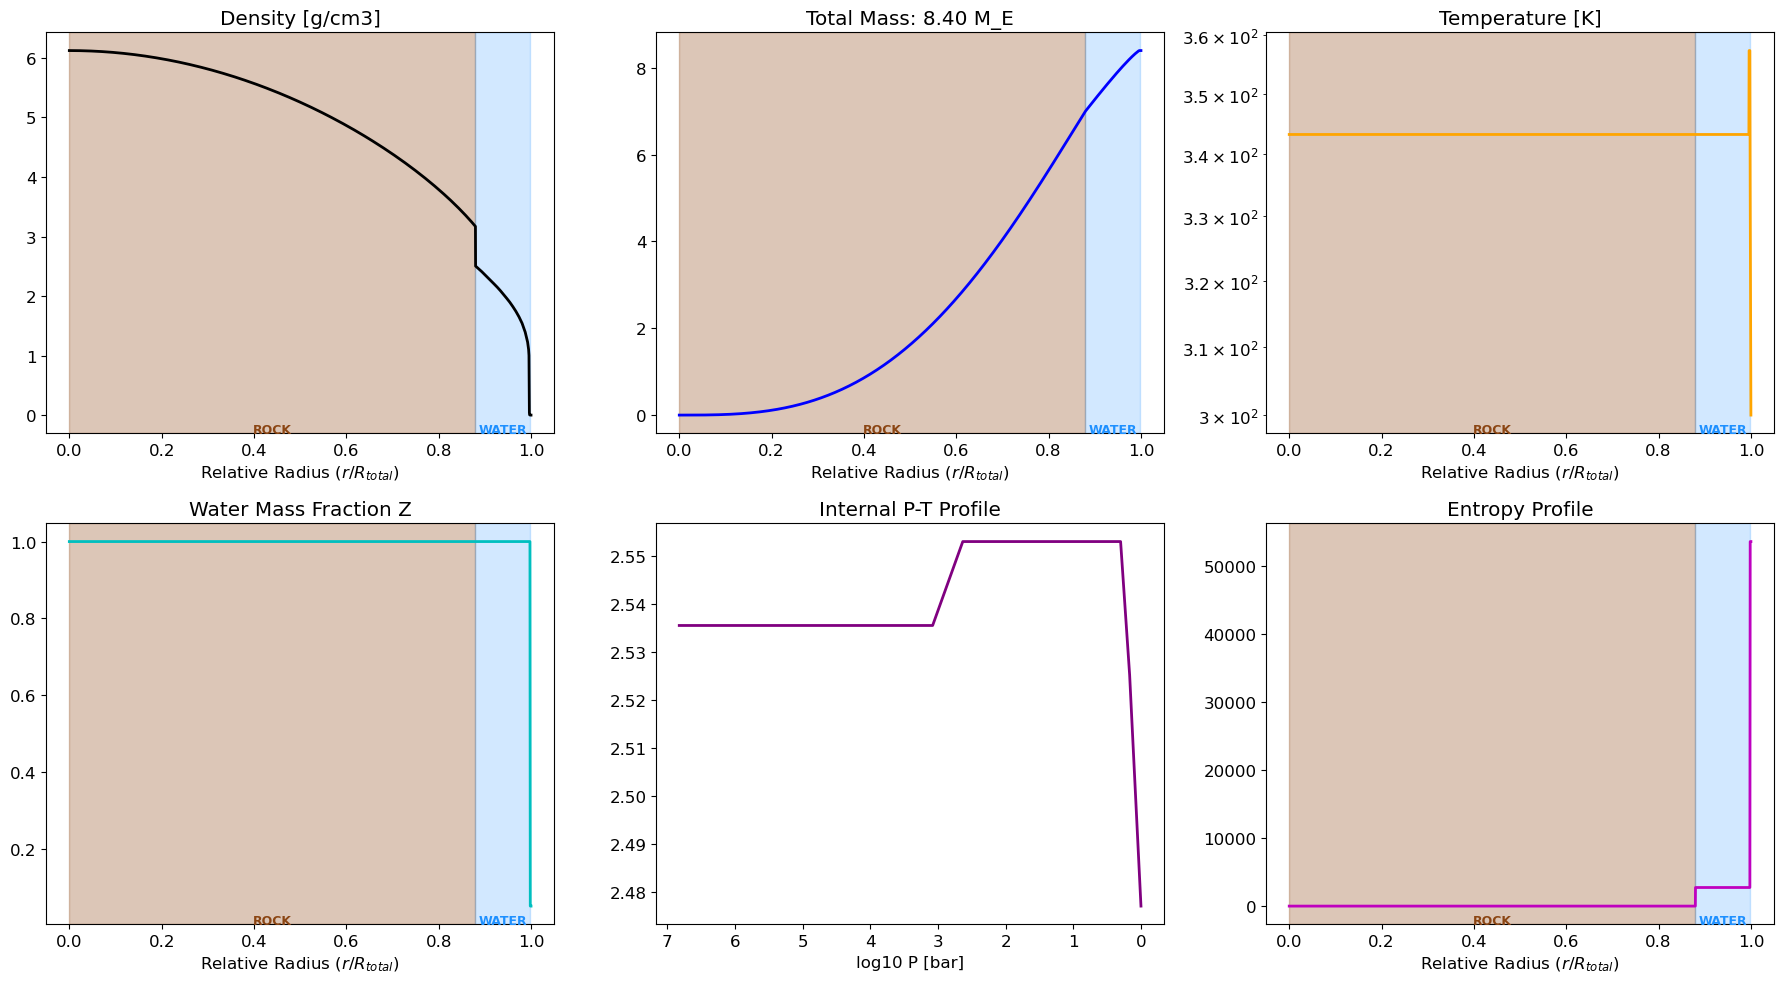

Figure saved to: ../figures/eos_trajectory.pdf


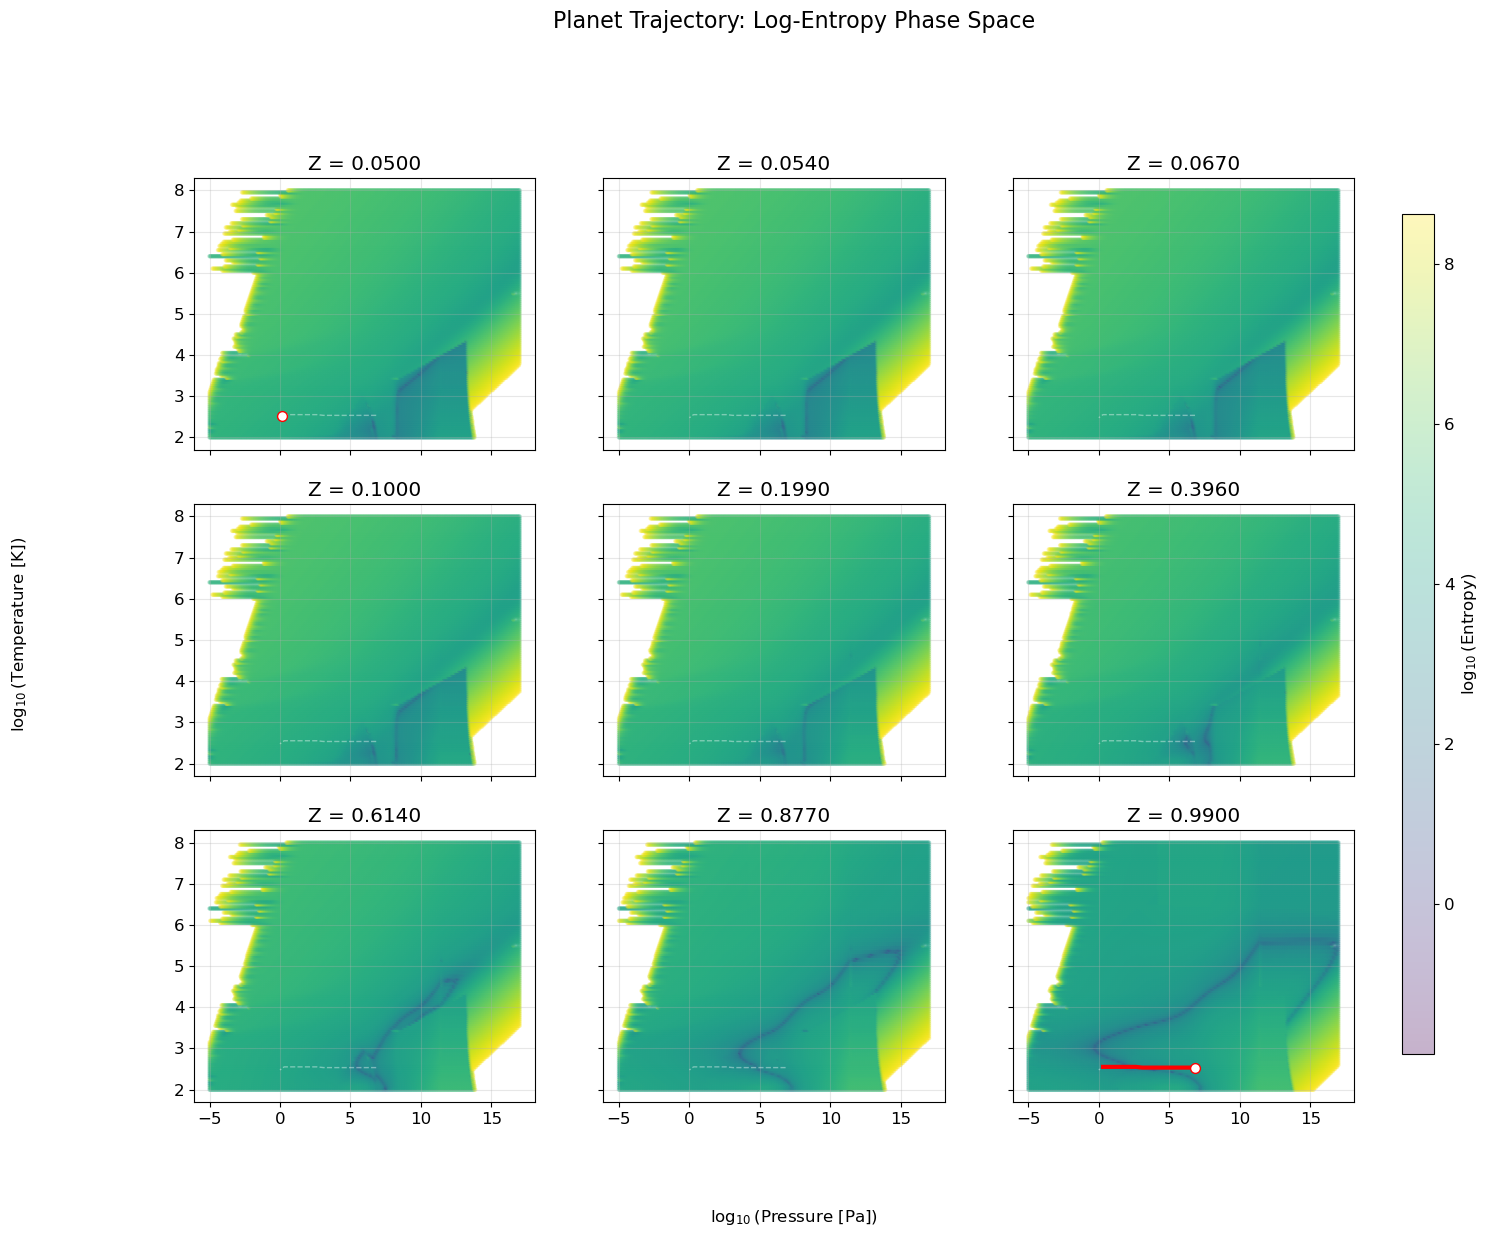

In [4]:

if result:
    print(f"Success! Final Mass: {result['M'][-1]/c.M_EARTH:.3f} Me")
    print(f"Success! Final Radius: {result['R'][-1]/c.R_EARTH:.3f} Me")
    # Diagnostics will show the water-to-gas transition
    plotting.plot_diagnostics(result, save_name="Kepler11e_structure")
    plotting.plot_trajectory_on_eos(result, params, max_plots=9, save_name="Kepler11e_trajetory")

In [3]:
result

{'M_total': 3.912165598998791e+25,
 'R_total': 8434137.376551986,
 'M_Z_total': 3.870215100212181e+25,
 'R_int': 8415479.208002213,
 'R_rock': 8406584.15582838,
 'P_center': 17585493.265604038,
 'R': array([8407235.40298888, 8415479.20800221, 8433574.7298484 ]),
 'M': array([3.09191923e+25, 3.83116412e+25, 3.91177434e+25]),
 'P': array([11.52678223, 10.56547616,  8.27760163]),
 'Rho': array([1831386.41071216, 1638614.11306289,   11110.49325844]),
 'Z': array([0.999 , 0.999 , 0.6078]),
 'T': array([ 3329.4765623, 11886.5514491,   100.       ]),
 'S': array([15836.73553468, 10694.10079662,  3077.60845626])}